In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os

base = '/kaggle/input/datasets/ecepelin/tcga-luad-lusc-copy-number'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # sadece ilk 2 seviyeyi göster
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:  # her klasörden ilk 5 dosya
            print(f'{subindent}{f}')

tcga-luad-lusc-copy-number/
  gdc_sample_sheet.2026-06-06.tsv
  tcga-luad-lusc-copy-number/
    gdc_manifest.2026-06-06.141519.txt
    gdc_sample_sheet.2026-06-06.tsv


In [8]:
import pandas as pd

# Labellara bak
labels = pd.read_csv('/kaggle/input/datasets/adicse09/tcga-pan-cancer/labels.csv')
print(labels.head(10))
print("\nUnique labels:", labels.iloc[:, 1].unique())
print("Value counts:\n", labels.iloc[:, 1].value_counts())

  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA
5   sample_5  PRAD
6   sample_6  KIRC
7   sample_7  PRAD
8   sample_8  BRCA
9   sample_9  PRAD

Unique labels: ['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']
Value counts:
 Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [10]:
data = pd.read_csv('/kaggle/input/datasets/adicse09/tcga-pan-cancer/data.csv', nrows=3)
print(data.iloc[:, :5])
print("\nShape:", data.shape)
print("\nColumn names sample:", list(data.columns[:10]))

  Unnamed: 0  gene_0    gene_1    gene_2    gene_3
0   sample_0     0.0  2.017209  3.265527  5.478487
1   sample_1     0.0  0.592732  1.588421  7.586157
2   sample_2     0.0  3.511759  4.327199  6.881787

Shape: (3, 20532)

Column names sample: ['Unnamed: 0', 'gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6', 'gene_7', 'gene_8']


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# Veriyi yükle
print("Veri yükleniyor...")
data = pd.read_csv('/kaggle/input/datasets/adicse09/tcga-pan-cancer/data.csv', index_col=0)
labels = pd.read_csv('/kaggle/input/datasets/adicse09/tcga-pan-cancer/labels.csv', index_col=0)

print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nSınıf dağılımı:\n{labels['Class'].value_counts()}")
print(f"\nEksik değer var mı: {data.isnull().sum().sum()}")

# Label encode
le = LabelEncoder()
y = le.fit_transform(labels['Class'])
X = data.values.astype(np.float32)

print(f"\nSınıflar: {le.classes_}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Veri yükleniyor...
Data shape: (801, 20531)
Labels shape: (801, 1)

Sınıf dağılımı:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

Eksik değer var mı: 0

Sınıflar: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
X shape: (801, 20531), y shape: (801,)


In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Torch tensörlere çevir
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)  # (N, 1, 20531) — 1 kanal
X_test_t  = torch.FloatTensor(X_test).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

print(f"Tensor shape: {X_train_t.shape}")

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

Train: (640, 20531), Test: (161, 20531)
Tensor shape: torch.Size([640, 1, 20531])

Device: cuda


In [15]:
device = torch.device('cpu')

# Modelleri yeniden oluştur
mlp         = MLP(input_dim, num_classes).to(device)
cnn         = CNN1D(num_classes).to(device)
transformer = TransformerClassifier(input_dim, num_classes).to(device)

# Tensörleri de CPU'ya al
X_train_t = X_train_t.to(device)
X_test_t  = X_test_t.to(device)
y_train_t = y_train_t.to(device)
y_test_t  = y_test_t.to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# Dummy forward ile LazyLinear'ı initialize et
dummy = torch.zeros(1, 1, input_dim).to(device)
_ = cnn(dummy)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"MLP params:         {count_params(mlp):,}")
print(f"CNN params:         {count_params(cnn):,}")
print(f"Transformer params: {count_params(transformer):,}")

MLP params:         10,578,693
CNN params:         2,631,141
Transformer params: 129,093


In [16]:
import time
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def train_model(model, train_loader, test_loader, epochs=30, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'test_acc': [], 'test_f1': []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                out   = model(X_batch)
                probs = torch.softmax(out, dim=1)
                preds = out.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        acc = (np.array(all_preds) == np.array(all_labels)).mean()
        f1  = f1_score(all_labels, all_preds, average='weighted')
        history['train_loss'].append(running_loss / len(train_loader))
        history['test_acc'].append(acc)
        history['test_f1'].append(f1)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

    elapsed = time.time() - start
    print(f"\nToplam süre: {elapsed:.1f}s")
    return history, elapsed, np.array(all_probs), np.array(all_labels)

# Üç modeli sırayla train et
print("=" * 50)
print("MLP Training")
print("=" * 50)
mlp_history, mlp_time, mlp_probs, mlp_labels = train_model(mlp, train_loader, test_loader)

print("\n" + "=" * 50)
print("CNN Training")
print("=" * 50)
cnn_history, cnn_time, cnn_probs, cnn_labels = train_model(cnn, train_loader, test_loader)

print("\n" + "=" * 50)
print("Transformer Training")
print("=" * 50)
tr_history, tr_time, tr_probs, tr_labels = train_model(transformer, train_loader, test_loader)

MLP Training
Epoch 5/30 | Loss: 1.0028 | Acc: 0.8385 | F1: 0.8075
Epoch 10/30 | Loss: 0.8848 | Acc: 0.7888 | F1: 0.7360
Epoch 15/30 | Loss: 0.9382 | Acc: 0.8820 | F1: 0.8391
Epoch 20/30 | Loss: 0.9937 | Acc: 0.7267 | F1: 0.6267
Epoch 25/30 | Loss: 1.0035 | Acc: 0.7578 | F1: 0.6847
Epoch 30/30 | Loss: 1.1120 | Acc: 0.9006 | F1: 0.8562

Toplam süre: 62.7s

CNN Training
Epoch 5/30 | Loss: 0.3511 | Acc: 0.9752 | F1: 0.9748
Epoch 10/30 | Loss: 0.1306 | Acc: 0.9752 | F1: 0.9748
Epoch 15/30 | Loss: 0.0891 | Acc: 0.9938 | F1: 0.9938
Epoch 20/30 | Loss: 0.0555 | Acc: 0.9938 | F1: 0.9938
Epoch 25/30 | Loss: 0.0455 | Acc: 0.9938 | F1: 0.9938
Epoch 30/30 | Loss: 0.0477 | Acc: 0.9938 | F1: 0.9938

Toplam süre: 135.4s

Transformer Training
Epoch 5/30 | Loss: 0.2135 | Acc: 0.9193 | F1: 0.9131
Epoch 10/30 | Loss: 0.1209 | Acc: 0.9317 | F1: 0.9311
Epoch 15/30 | Loss: 0.1083 | Acc: 0.9193 | F1: 0.9187
Epoch 20/30 | Loss: 0.0610 | Acc: 0.9317 | F1: 0.9308
Epoch 25/30 | Loss: 0.0100 | Acc: 0.9814 | F1: 0.

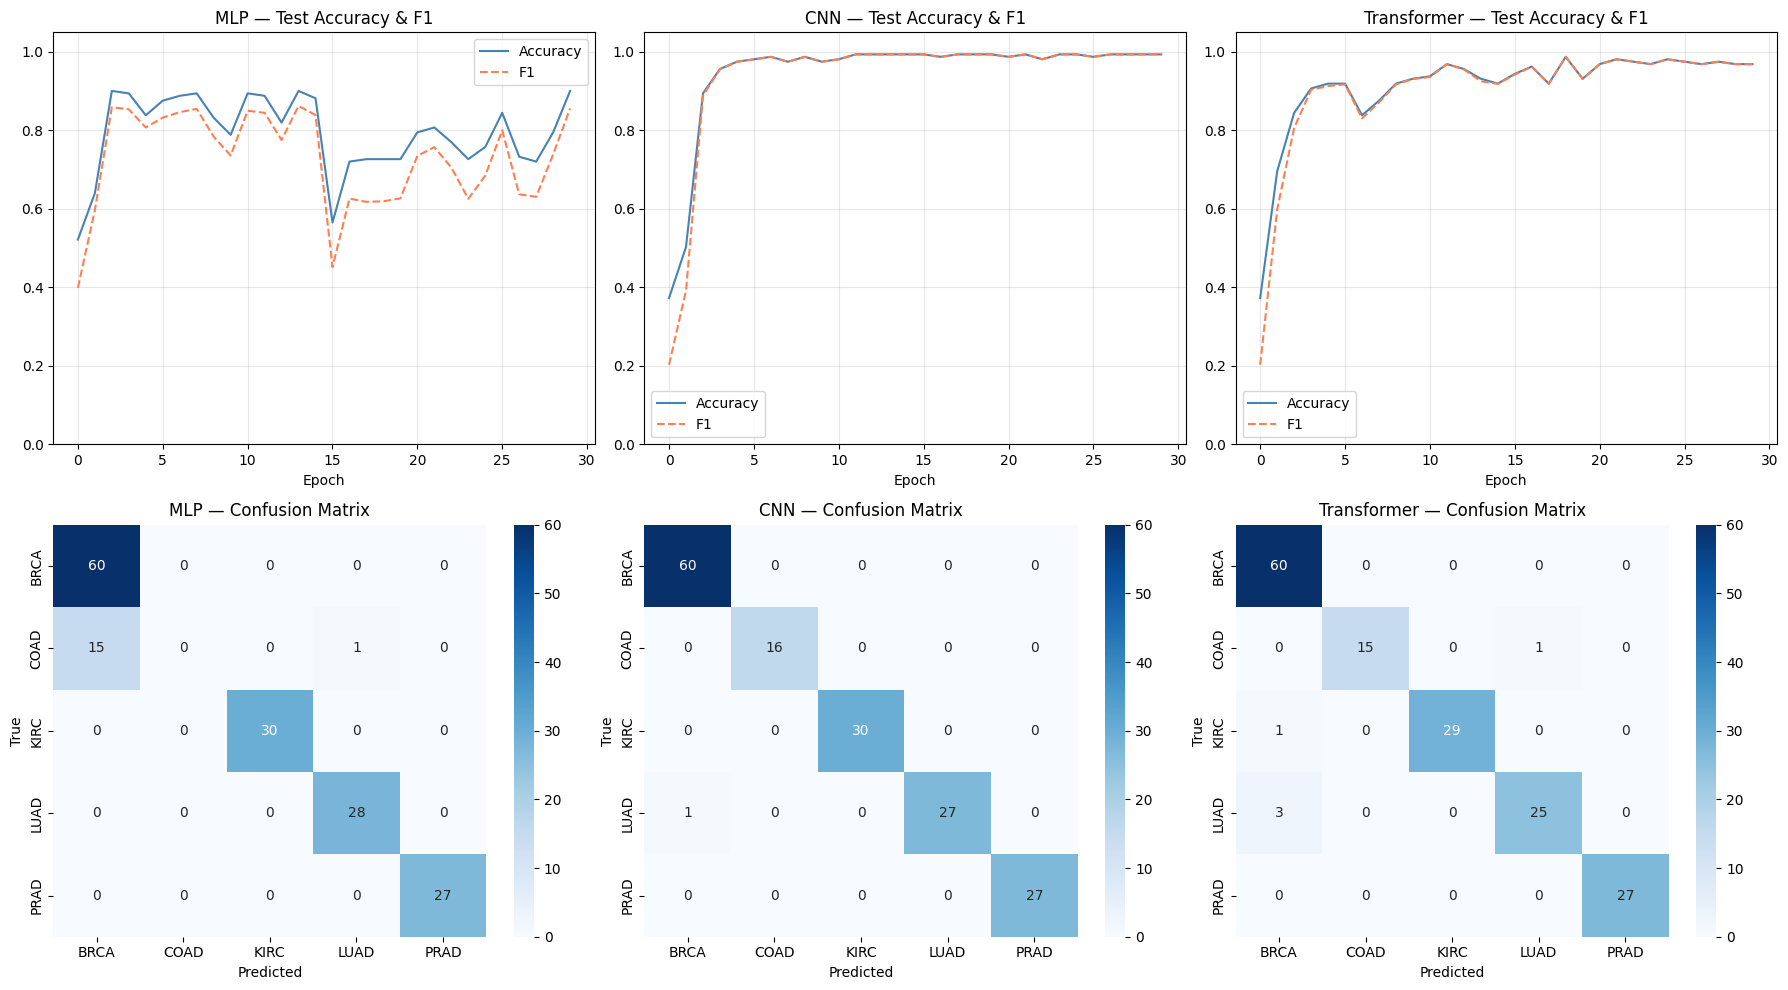

Kaydedildi!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_data = [
    ('MLP',         mlp_history,  mlp_probs,  mlp_labels),
    ('CNN',         cnn_history,  cnn_probs,  cnn_labels),
    ('Transformer', tr_history,   tr_probs,   tr_labels),
]

# Üst sıra: accuracy curves
for i, (name, hist, _, _) in enumerate(models_data):
    axes[0, i].plot(hist['test_acc'], label='Accuracy', color='steelblue')
    axes[0, i].plot(hist['test_f1'],  label='F1',       color='coral', linestyle='--')
    axes[0, i].set_title(f'{name} — Test Accuracy & F1')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylim(0, 1.05)
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Alt sıra: confusion matrices
for i, (name, _, probs, labels_arr) in enumerate(models_data):
    preds = probs.argmax(axis=1)
    cm    = confusion_matrix(labels_arr, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[1, i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Blues')
    axes[1, i].set_title(f'{name} — Confusion Matrix')
    axes[1, i].set_xlabel('Predicted')
    axes[1, i].set_ylabel('True')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi!")

In [18]:
# Final karşılaştırma tablosu
from sklearn.metrics import classification_report

results = {
    'Model':      ['MLP',         'CNN',         'Transformer'],
    'Test Acc':   [f"{mlp_history['test_acc'][-1]:.4f}",
                   f"{cnn_history['test_acc'][-1]:.4f}",
                   f"{tr_history['test_acc'][-1]:.4f}"],
    'Test F1':    [f"{mlp_history['test_f1'][-1]:.4f}",
                   f"{cnn_history['test_f1'][-1]:.4f}",
                   f"{tr_history['test_f1'][-1]:.4f}"],
    'Params':     [f"{count_params(mlp):,}",
                   f"{count_params(cnn):,}",
                   f"{count_params(transformer):,}"],
    'Train Time': [f"{mlp_time:.1f}s",
                   f"{cnn_time:.1f}s",
                   f"{tr_time:.1f}s"],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print()

# CNN için detaylı classification report
preds_cnn = cnn_probs.argmax(axis=1)
print("CNN — Detailed Report:")
print(classification_report(cnn_labels, preds_cnn, target_names=le.classes_))

      Model Test Acc Test F1     Params Train Time
        MLP   0.9006  0.8562 10,578,693      62.7s
        CNN   0.9938  0.9938  2,631,141     135.4s
Transformer   0.9689  0.9687    129,093     841.9s

CNN — Detailed Report:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161

